In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


In [15]:
# 1. Podesavanje uređaja (FORCE CPU ili GPU ako je dostupan)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristi se uređaj:", device)

Koristi se uređaj: cuda


In [10]:
# 2. Priprema podataka - DIREKTNO U MEMORIJU
train_dataset = datasets.MNIST(root='./data', train=True, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)

# Ekstrakcija, skaliranje (0-1) i dodavanje dimenzije kanala (1, 28, 28)
x_train = train_dataset.data.float().unsqueeze(1) / 255.0
y_train = train_dataset.targets

x_test = test_dataset.data.float().unsqueeze(1) / 255.0
y_test = test_dataset.targets

# Premeštanje kompletnog skupa podataka na uređaj (CPU/GPU) UNAPRED
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

print(f"Trening podaci: {x_train.shape}, Test podaci: {x_test.shape}")

Trening podaci: torch.Size([60000, 1, 28, 28]), Test podaci: torch.Size([10000, 1, 28, 28])


In [11]:
# 3. Arhitektura mreže (Ekvivalent za Sequential)
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.Tanh(),
            nn.Linear(256, 10),
            # Napomena: Softmax izostavljamo jer ga nn.CrossEntropyLoss interno primenjuje.
        )

    def forward(self, x):
        return self.net(x)

model = MNISTModel().to(device)
print(model)

MNISTModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): Tanh()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [12]:
# 4. Optimizator i Loss funkcija (Ekvivalent za model.compile)
# nn.CrossEntropyLoss je ekvivalent za sparse_categorical_crossentropy
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [13]:
# 5. Treniranje (Ekvivalent za model.fit i čuvanje 'hist' objekta)
epochs = 100
batch_size = 2048
num_train = x_train.shape[0]
num_test = x_test.shape[0]

history = {
    'loss': [], 'val_loss': [],
    'accuracy': [], 'val_accuracy': []
}

for epoch in range(epochs):
    # TRENING FAZA
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Generisanje nasumičnih indeksa za mešanje podataka (shuffle)
    indices = torch.randperm(num_train, device=device)

    # Ručna iteracija kroz batch-eve
    for i in range(0, num_train, batch_size):
        batch_idx = indices[i : i + batch_size]

        # Očitavanje iz memorije je sada trenutno
        images = x_train[batch_idx]
        labels = y_train[batch_idx]

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrike
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / num_train
    epoch_acc = correct_train / num_train

    # VALIDACIONA FAZA
    model.eval()
    val_loss = 0.0
    correct_val = 0

    with torch.no_grad():
        # Za validaciju nam ne treba shuffle, idemo redom
        for i in range(0, num_test, batch_size):
            images = x_test[i : i + batch_size]
            labels = y_test[i : i + batch_size]

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / num_test
    epoch_val_acc = correct_val / num_test

    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f} - "
              f"val_loss: {epoch_val_loss:.4f} - val_acc: {epoch_val_acc:.4f}")

Epoch [1/100] - loss: 1.7428 - acc: 0.6490 - val_loss: 1.1800 - val_acc: 0.7873
Epoch [11/100] - loss: 0.3647 - acc: 0.8985 - val_loss: 0.3446 - val_acc: 0.9047
Epoch [21/100] - loss: 0.3117 - acc: 0.9113 - val_loss: 0.2989 - val_acc: 0.9163
Epoch [31/100] - loss: 0.2862 - acc: 0.9188 - val_loss: 0.2777 - val_acc: 0.9214
Epoch [41/100] - loss: 0.2670 - acc: 0.9244 - val_loss: 0.2615 - val_acc: 0.9254
Epoch [51/100] - loss: 0.2498 - acc: 0.9292 - val_loss: 0.2461 - val_acc: 0.9292
Epoch [61/100] - loss: 0.2335 - acc: 0.9340 - val_loss: 0.2306 - val_acc: 0.9345
Epoch [71/100] - loss: 0.2178 - acc: 0.9386 - val_loss: 0.2168 - val_acc: 0.9386
Epoch [81/100] - loss: 0.2033 - acc: 0.9433 - val_loss: 0.2037 - val_acc: 0.9414
Epoch [91/100] - loss: 0.1902 - acc: 0.9465 - val_loss: 0.1913 - val_acc: 0.9462
Epoch [100/100] - loss: 0.1795 - acc: 0.9500 - val_loss: 0.1818 - val_acc: 0.9488


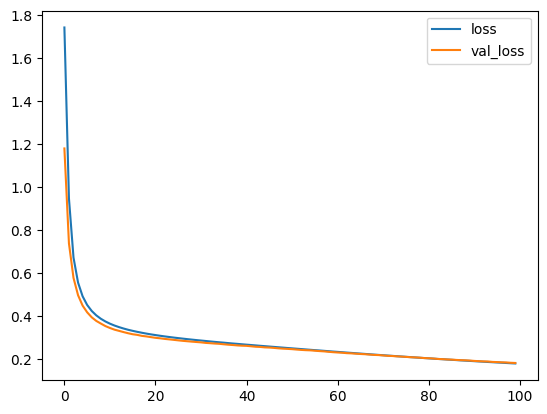

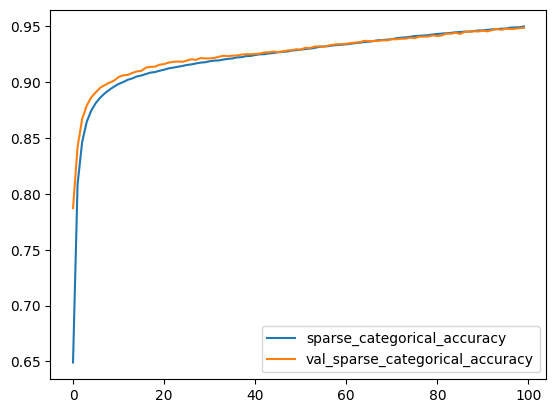

In [14]:
# 6. Crtanje grafika
plt.plot(history['loss'], label='loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.clf()

plt.plot(history['accuracy'], label='sparse_categorical_accuracy')
plt.plot(history['val_accuracy'], label='val_sparse_categorical_accuracy')
plt.legend()
plt.show()